In [2]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   PINN — Ecuación de Schrödinger Radial · Electrón de Valencia del Litio   ║
║   Physics-Informed Neural Network                                           ║
╚══════════════════════════════════════════════════════════════════════════════╝

Problema físico
───────────────
  −½ u″(r) + V_eff(r) u(r) = E u(r)          (unidades atómicas)

  V_eff(r) = −1/r − (2/r)(1 + αr)e^{−2αr} + l(l+1)/(2r²)
  α = 2.535930  (parámetro variacional del átomo de litio)

Estrategia PINN
───────────────
  La función de onda u(r) se parametriza como una red neuronal.
  La pérdida total combina:
    L_data   → ajuste a los datos de diferencias finitas  (datos discretos)
    L_phys   → residuo de la EDP (Schrödinger) en puntos de colocación
    L_bc     → condiciones de frontera: u(r_min)≈0,  u(r_max)≈0

  La red se entrena por separado para cada estado cuántico.

Formato del archivo .dat
────────────────────────
  r   psi_1   psi_2   psi_3   psi_4   psi_5   psi_6   psi_7
  (separados por tabulaciones o espacios)

Uso
───
  1. Ajusta DATA_FILE con la ruta a tu archivo .dat.
  2. Ajusta STATES si el orden de columnas difiere.
  3. Ejecuta:  python pinn_litio.py

Requisitos
──────────
  pip install torch numpy matplotlib scipy
"""

# ─── Importaciones ─────────────────────────────────────────────────────────────
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN — ajusta estos parámetros
# ═══════════════════════════════════════════════════════════════════════════════

DATA_FILE = "LITIO.dat"          # ruta al archivo de diferencias finitas

ALPHA = 2.535930                 # parámetro variacional α (u.a.)
HARTREE_TO_EV = 27.2114          # factor de conversión

# Estados cuánticos  ← ajusta 'col' si el orden en tu .dat es distinto
# col=0 → r,  col=1 → psi_1, ...
STATES = [
    {"name": "2s",  "l": 0,  "E_eV": -4.6994,  "col": 1},
    {"name": "3s",  "l": 0,  "E_eV": -1.8527,  "col": 2},
    {"name": "4s",  "l": 0,  "E_eV": -0.7201,  "col": 3},
    {"name": "2p",  "l": 1,  "E_eV": -3.4306,  "col": 4},
    {"name": "3p",  "l": 1,  "E_eV": -1.5050,  "col": 5},
    {"name": "3d",  "l": 2,  "E_eV": -1.5048,  "col": 6},
    # Si tienes una 7ª columna, descomenta y ajusta:
    # {"name": "4p",  "l": 1,  "E_eV": -0.850,   "col": 7},
]

# Hiperparámetros del entrenamiento
HIDDEN_LAYERS  = 5         # número de capas ocultas
NEURONS        = 64        # neuronas por capa
EPOCHS         = 15_000    # épocas de entrenamiento
LR             = 1e-3      # tasa de aprendizaje inicial
LR_DECAY_STEP  = 5_000     # cada cuántas épocas se reduce lr
LR_DECAY_GAMMA = 0.5       # factor de reducción
N_COLLOC       = 800       # puntos de colocación para L_phys
LAMBDA_PHYS    = 0.05      # peso de la pérdida física
LAMBDA_BC      = 10.0      # peso de las condiciones de frontera
PRINT_EVERY    = 1_000     # frecuencia de reporte en consola

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ═══════════════════════════════════════════════════════════════════════════════
#  POTENCIAL EFECTIVO
# ═══════════════════════════════════════════════════════════════════════════════

def V_eff(r: torch.Tensor, l: int) -> torch.Tensor:
    """
    Potencial efectivo en unidades atómicas.
    
      V(r) = −1/r − (2/r)(1 + αr)e^{−2αr} + l(l+1)/(2r²)
    
    Parámetros
    ----------
    r : tensor de coordenadas radiales (positivas)
    l : número cuántico de momento angular
    """
    alpha = ALPHA
    V = -1.0 / r - (2.0 / r) * (1.0 + alpha * r) * torch.exp(-2.0 * alpha * r)
    if l > 0:
        V = V + l * (l + 1) / (2.0 * r ** 2)
    return V

# ═══════════════════════════════════════════════════════════════════════════════
#  ARQUITECTURA DE LA RED NEURONAL
# ═══════════════════════════════════════════════════════════════════════════════

class PINN(nn.Module):
    """
    Red neuronal completamente conectada: R → R.

    Entrada : r  (coordenada radial escalada)
    Salida  : u(r) (función de onda radial reducida)

    Activación: Tanh (suave, diferenciable dos veces → necesario para u″)
    """

    def __init__(self, hidden_layers: int = 5, neurons: int = 64):
        super().__init__()

        layers: list[nn.Module] = [nn.Linear(1, neurons), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(neurons, neurons), nn.Tanh()]
        layers.append(nn.Linear(neurons, 1))

        self.net = nn.Sequential(*layers)
        self._xavier_init()

    def _xavier_init(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, r: torch.Tensor) -> torch.Tensor:
        return self.net(r)


# ═══════════════════════════════════════════════════════════════════════════════
#  FUNCIONES DE PÉRDIDA
# ═══════════════════════════════════════════════════════════════════════════════

def schrodinger_residual(
    model: PINN,
    r: torch.Tensor,
    E_au: float,
    l: int,
) -> torch.Tensor:
    """
    Residuo de la ecuación de Schrödinger:

        f(r) = −½ u″(r) + V_eff(r) u(r) − E u(r)  ≡ 0

    Se calcula con diferenciación automática (autograd) de segundo orden.
    """
    r = r.requires_grad_(True)

    u = model(r)

    # Primera derivada u′
    u_r = grad(
        u, r,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]

    # Segunda derivada u″
    u_rr = grad(
        u_r, r,
        grad_outputs=torch.ones_like(u_r),
        create_graph=True,
        retain_graph=True,
    )[0]

    V = V_eff(r, l)
    residual = -0.5 * u_rr + V * u - E_au * u
    return residual


def compute_losses(
    model: PINN,
    r_data: torch.Tensor,
    u_data: torch.Tensor,
    r_col: torch.Tensor,
    r_bc_left: torch.Tensor,
    r_bc_right: torch.Tensor,
    E_au: float,
    l: int,
) -> tuple[torch.Tensor, dict]:
    """
    Calcula las tres componentes de la pérdida total.

    Returns
    -------
    loss_total, dict con pérdidas individuales
    """
    # 1. Pérdida de datos (ajuste a diferencias finitas)
    u_pred = model(r_data)
    L_data = nn.functional.mse_loss(u_pred, u_data)

    # 2. Pérdida física (residuo de Schrödinger en puntos de colocación)
    res = schrodinger_residual(model, r_col.clone(), E_au, l)
    L_phys = torch.mean(res ** 2)

    # 3. Condiciones de frontera
    L_bc = model(r_bc_left) ** 2 + model(r_bc_right) ** 2
    L_bc = L_bc.mean()

    loss_total = L_data + LAMBDA_PHYS * L_phys + LAMBDA_BC * L_bc

    return loss_total, {
        "data":   L_data.item(),
        "phys":   L_phys.item(),
        "bc":     L_bc.item(),
        "total":  loss_total.item(),
    }


# ═══════════════════════════════════════════════════════════════════════════════
#  NORMALIZACIÓN DE LOS DATOS
# ═══════════════════════════════════════════════════════════════════════════════

def normalize_r(r: np.ndarray) -> tuple[np.ndarray, float, float]:
    """Normaliza r a [0, 1] y devuelve (r_norm, r_min, r_max)."""
    r_min, r_max = r.min(), r.max()
    return (r - r_min) / (r_max - r_min), r_min, r_max


def denormalize_r(r_norm: np.ndarray, r_min: float, r_max: float) -> np.ndarray:
    return r_norm * (r_max - r_min) + r_min


# ═══════════════════════════════════════════════════════════════════════════════
#  BUCLE DE ENTRENAMIENTO
# ═══════════════════════════════════════════════════════════════════════════════

def train_pinn(
    state: dict,
    r_raw: np.ndarray,
    u_raw: np.ndarray,
) -> tuple[PINN, dict, float, float]:
    """
    Entrena una PINN para un único estado cuántico.

    Parameters
    ----------
    state : diccionario con name, l, E_eV
    r_raw : coordenadas radiales (u.a.)
    u_raw : función de onda de diferencias finitas

    Returns
    -------
    model, history, r_min, r_max
    """
    name = state["name"]
    l    = state["l"]
    E_au = state["E_eV"] / HARTREE_TO_EV

    print(f"\n{'═'*60}")
    print(f"  Entrenando PINN  |  Estado: {name}  |  l={l}  |  E={E_au:.5f} u.a.")
    print(f"{'═'*60}")

    # ── Preprocesamiento ────────────────────────────────────────────────────────
    # Normalizar amplitud de la función de onda
    u_max = np.max(np.abs(u_raw))
    u_norm = u_raw / (u_max + 1e-12)

    # Normalizar r → [0, 1]
    r_norm, r_min, r_max = normalize_r(r_raw)

    # Tensores de entrenamiento
    r_t = torch.tensor(r_norm,  dtype=torch.float32).unsqueeze(1).to(DEVICE)
    u_t = torch.tensor(u_norm,  dtype=torch.float32).unsqueeze(1).to(DEVICE)

    # Puntos de colocación uniformes
    r_col = torch.linspace(
        float(r_norm[1]),        # evitar r=0 (singularidad)
        float(r_norm[-1]),
        N_COLLOC,
        dtype=torch.float32,
    ).unsqueeze(1).to(DEVICE)

    # Condiciones de frontera
    r_bc_left  = torch.tensor([[r_norm[0]]], dtype=torch.float32).to(DEVICE)
    r_bc_right = torch.tensor([[r_norm[-1]]], dtype=torch.float32).to(DEVICE)

    # ── Modelo y optimizador ────────────────────────────────────────────────────
    model = PINN(hidden_layers=HIDDEN_LAYERS, neurons=NEURONS).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=LR_DECAY_STEP, gamma=LR_DECAY_GAMMA
    )

    # ── Historial de pérdidas ───────────────────────────────────────────────────
    history: dict[str, list] = {"total": [], "data": [], "phys": [], "bc": []}

    # ── Bucle de entrenamiento ──────────────────────────────────────────────────
    for epoch in range(1, EPOCHS + 1):
        optimizer.zero_grad()

        loss_total, losses = compute_losses(
            model, r_t, u_t, r_col, r_bc_left, r_bc_right, E_au, l
        )

        loss_total.backward()
        optimizer.step()
        scheduler.step()

        if epoch % PRINT_EVERY == 0 or epoch == 1:
            for k, v in losses.items():
                history[k].append(v)

            print(
                f"  Época {epoch:>6d}/{EPOCHS}  |  "
                f"Total {losses['total']:.3e}  |  "
                f"Datos {losses['data']:.3e}  |  "
                f"Física {losses['phys']:.3e}  |  "
                f"CC {losses['bc']:.3e}"
            )

    print(f"  ✓ Entrenamiento completado — Estado {name}")
    return model, history, r_min, r_max


# ═══════════════════════════════════════════════════════════════════════════════
#  CARGA DE DATOS
# ═══════════════════════════════════════════════════════════════════════════════

def load_data(filepath: str) -> np.ndarray:
    """
    Carga el archivo .dat con columnas: r psi_1 psi_2 ... psi_7
    Acepta separadores de tabulación o espacios múltiples.
    Ignora líneas en blanco y comentarios (#).
    """
    path = Path(filepath)
    if not path.exists():
        print(f"\n[ERROR] No se encontró el archivo: {filepath}")
        print("        Ajusta DATA_FILE al inicio del script.")
        sys.exit(1)

    data = np.loadtxt(filepath, comments="#")
    print(f"  Datos cargados: {data.shape[0]} puntos × {data.shape[1]} columnas")
    return data


# ═══════════════════════════════════════════════════════════════════════════════
#  PREDICCIÓN Y EVALUACIÓN
# ═══════════════════════════════════════════════════════════════════════════════

def predict(
    model: PINN,
    r_raw: np.ndarray,
    r_min: float,
    r_max: float,
    u_scale: float,
    n_points: int = 1000,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Genera predicción continua de la PINN en una malla densa.

    Returns
    -------
    r_dense, u_pred  (en unidades originales)
    """
    r_dense = np.linspace(r_raw[1], r_raw[-1], n_points)
    r_norm  = (r_dense - r_min) / (r_max - r_min)

    r_t = torch.tensor(r_norm, dtype=torch.float32).unsqueeze(1).to(DEVICE)

    model.eval()
    with torch.no_grad():
        u_pred_norm = model(r_t).cpu().numpy().squeeze()
    model.train()

    return r_dense, u_pred_norm * u_scale


def compute_L2_error(
    u_fd: np.ndarray,
    u_pinn: np.ndarray,
) -> float:
    """Error relativo L2 entre diferencias finitas y PINN."""
    norm_fd = np.linalg.norm(u_fd)
    if norm_fd < 1e-12:
        return float("nan")
    return np.linalg.norm(u_fd - u_pinn) / norm_fd


# ═══════════════════════════════════════════════════════════════════════════════
#  VISUALIZACIÓN
# ═══════════════════════════════════════════════════════════════════════════════

def plot_results(
    results: list[dict],
    save_fig: bool = True,
    output_dir: str = ".",
):
    """
    Genera dos figuras:
      1. Funciones de onda: FD vs PINN para cada estado.
      2. Curvas de pérdida durante el entrenamiento.
    """
    n = len(results)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    # ── Figura 1: Funciones de onda ─────────────────────────────────────────────
    fig1, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for idx, res in enumerate(results):
        ax = axes[idx]
        ax.plot(res["r_fd"], res["u_fd"],
                "o", ms=3, color="#4C72B0", label="Dif. Finitas", alpha=0.7)
        ax.plot(res["r_dense"], res["u_pinn"],
                "-",  lw=2, color="#C44E52", label="PINN")
        ax.set_title(
            f"Estado {res['name']}  (l={res['l']})\n"
            f"E = {res['E_eV']:.4f} eV   |   L₂ = {res['L2']:.2e}",
            fontsize=10,
        )
        ax.set_xlabel("r (u.a.)")
        ax.set_ylabel("u(r)")
        ax.legend(fontsize=8)
        ax.grid(True, ls="--", alpha=0.4)

    # Ocultar ejes vacíos
    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig1.suptitle(
        "PINN — Funciones de onda del electrón de valencia del Litio",
        fontsize=13, fontweight="bold",
    )
    fig1.tight_layout()
    if save_fig:
        p1 = os.path.join(output_dir, "pinn_wavefunctions.pdf")
        fig1.savefig(p1, dpi=150, bbox_inches="tight")
        print(f"  Figura guardada → {p1}")

    # ── Figura 2: Curvas de pérdida ─────────────────────────────────────────────
    fig2, axes2 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
    axes2 = np.array(axes2).flatten()

    for idx, res in enumerate(results):
        ax = axes2[idx]
        hist = res["history"]
        epochs_rec = np.arange(1, len(hist["total"]) + 1) * PRINT_EVERY

        ax.semilogy(epochs_rec, hist["total"], label="Total",  lw=1.8)
        ax.semilogy(epochs_rec, hist["data"],  label="Datos",  lw=1.4, ls="--")
        ax.semilogy(epochs_rec, hist["phys"],  label="Física", lw=1.4, ls="-.")
        ax.semilogy(epochs_rec, hist["bc"],    label="CC",     lw=1.4, ls=":")
        ax.set_title(f"Pérdidas — {res['name']}", fontsize=10)
        ax.set_xlabel("Época")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=7)
        ax.grid(True, ls="--", alpha=0.4)

    for j in range(idx + 1, len(axes2)):
        axes2[j].set_visible(False)

    fig2.suptitle(
        "PINN — Evolución de pérdidas durante el entrenamiento",
        fontsize=13, fontweight="bold",
    )
    fig2.tight_layout()
    if save_fig:
        p2 = os.path.join(output_dir, "pinn_losses.pdf")
        fig2.savefig(p2, dpi=150, bbox_inches="tight")
        print(f"  Figura guardada → {p2}")

    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
#  TABLA DE RESUMEN
# ═══════════════════════════════════════════════════════════════════════════════

def print_summary(results: list[dict]):
    header = (
        f"\n{'─'*70}\n"
        f"  {'Estado':<8} {'l':<4} {'E_calc (eV)':<14} {'E_exp (eV)':<14}"
        f"  {'Error L2':<12}  {'Col. datos'}\n"
        f"{'─'*70}"
    )
    EXP = {"2s": -5.39, "3s": -2.02, "4s": -1.05,
           "2p": -3.54, "3p": -1.56, "3d": -1.51}
    print(header)
    for res in results:
        exp = EXP.get(res["name"], float("nan"))
        print(
            f"  {res['name']:<8} {res['l']:<4} {res['E_eV']:<14.4f}"
            f" {exp:<14.4f}  {res['L2']:<12.3e}  psi_{res['col']}"
        )
    print(f"{'─'*70}\n")


# ═══════════════════════════════════════════════════════════════════════════════
#  PUNTO DE ENTRADA
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    print(f"\n{'═'*60}")
    print("  PINN — Espectro del electrón de valencia del Litio")
    print(f"  Dispositivo: {DEVICE}")
    print(f"{'═'*60}\n")

    # ── Cargar datos ────────────────────────────────────────────────────────────
    print(f"  Leyendo datos desde: {DATA_FILE}")
    data = load_data(DATA_FILE)
    r_raw = data[:, 0]

    # ── Entrenamiento por estado ────────────────────────────────────────────────
    results = []
    for state in STATES:
        col = state["col"]
        if col >= data.shape[1]:
            print(f"  [AVISO] Columna {col} no existe en el archivo — "
                  f"omitiendo estado {state['name']}")
            continue

        u_raw = data[:, col]

        # Escala para desnormalizar la predicción
        u_scale = np.max(np.abs(u_raw))

        # Entrenar PINN
        model, history, r_min, r_max = train_pinn(state, r_raw, u_raw)

        # Predicción densa
        r_dense, u_pinn_dense = predict(
            model, r_raw, r_min, r_max, u_scale, n_points=2000
        )

        # Predicción en los puntos originales (para calcular L2)
        _, u_pinn_data = predict(
            model, r_raw, r_min, r_max, u_scale, n_points=len(r_raw)
        )
        # Interpolar u_pinn_data a los mismos r que u_raw
        u_pinn_interp = np.interp(r_raw, r_dense, u_pinn_dense)
        L2 = compute_L2_error(u_raw, u_pinn_interp)

        results.append({
            "name":    state["name"],
            "l":       state["l"],
            "E_eV":    state["E_eV"],
            "col":     col,
            "r_fd":    r_raw,
            "u_fd":    u_raw,
            "r_dense": r_dense,
            "u_pinn":  u_pinn_dense,
            "history": history,
            "L2":      L2,
            "model":   model,
        })

        # Guardar modelo
        model_path = f"pinn_{state['name']}.pt"
        torch.save(model.state_dict(), model_path)
        print(f"  Modelo guardado → {model_path}")

    # ── Resumen y gráficas ──────────────────────────────────────────────────────
    print_summary(results)
    plot_results(results, save_fig=True, output_dir=".")


if __name__ == "__main__":
    main()


════════════════════════════════════════════════════════════
  PINN — Espectro del electrón de valencia del Litio
  Dispositivo: cpu
════════════════════════════════════════════════════════════

  Leyendo datos desde: LITIO.dat

[ERROR] No se encontró el archivo: LITIO.dat
        Ajusta DATA_FILE al inicio del script.


SystemExit: 1


[INFO] DATA_FILE actualizado a: /home/isabel/MFC/PARCIAL/finite-diferences/funciones_radiales_litio_fortran_leonardo.DAT

════════════════════════════════════════════════════════════
  PINN — Espectro del electrón de valencia del Litio
  Dispositivo: cpu
════════════════════════════════════════════════════════════

  Leyendo datos desde: /home/isabel/MFC/PARCIAL/finite-diferences/funciones_radiales_litio_fortran_leonardo.DAT
  Datos cargados: 600 puntos × 8 columnas

════════════════════════════════════════════════════════════
  Entrenando PINN  |  Estado: 2s  |  l=0  |  E=-0.17270 u.a.
════════════════════════════════════════════════════════════
  Época      1/15000  |  Total 4.269e-01  |  Datos 4.977e-02  |  Física 1.001e-01  |  CC 3.722e-02
  Época   1000/15000  |  Total 3.556e-02  |  Datos 3.556e-02  |  Física 1.480e-04  |  CC 3.881e-08
  Época   2000/15000  |  Total 3.555e-02  |  Datos 3.553e-02  |  Física 3.492e-04  |  CC 7.356e-09
  Época   3000/15000  |  Total 3.555e-02  |  Da

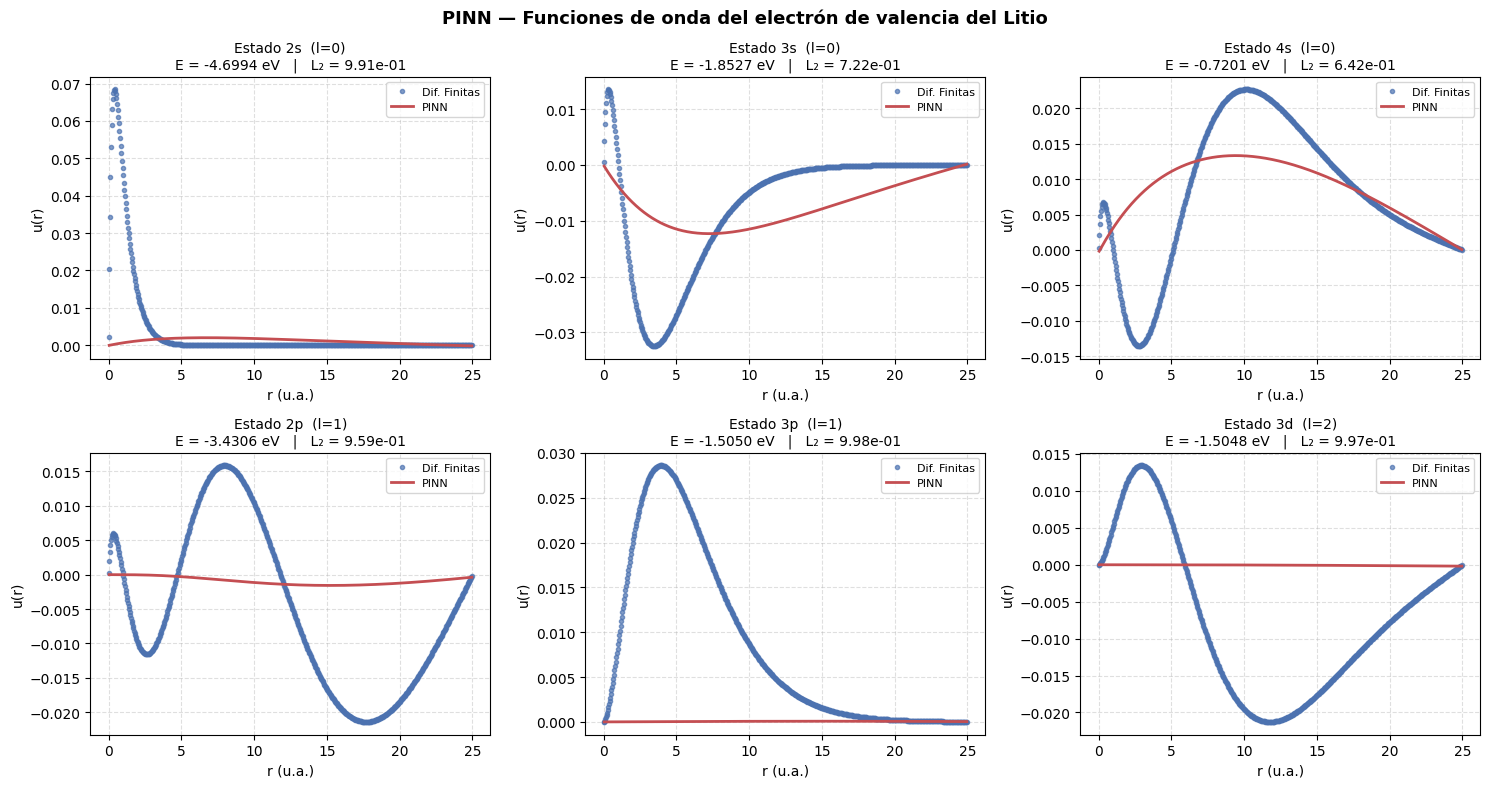

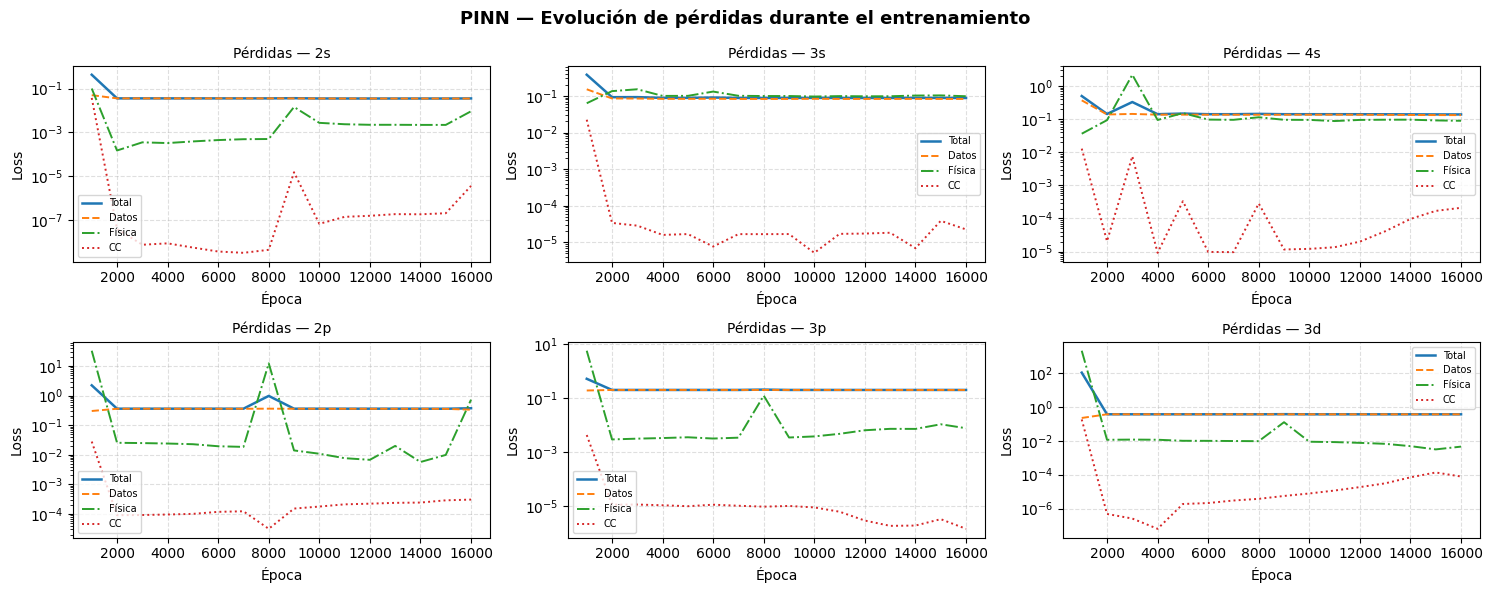

In [4]:
# Parche de integración de datos: usa el archivo Fortran directamente
DATA_FILE = "/home/isabel/MFC/PARCIAL/finite-diferences/funciones_radiales_litio_fortran_leonardo.DAT"

# Reemplazo robusto del loader para aceptar encabezado tipo: r psi_1 psi_2 ...
def load_data(filepath: str) -> np.ndarray:
    path = Path(filepath)
    if not path.exists():
        print(f"\n[ERROR] No se encontró el archivo: {filepath}")
        print("        Ajusta DATA_FILE al inicio del script.")
        sys.exit(1)

    with open(path, "r", encoding="utf-8") as f:
        first_line = f.readline().strip()

    has_header = any(ch.isalpha() for ch in first_line)
    skiprows = 1 if has_header else 0

    data = np.loadtxt(filepath, comments="#", skiprows=skiprows)
    print(f"  Datos cargados: {data.shape[0]} puntos × {data.shape[1]} columnas")
    return data

print(f"\n[INFO] DATA_FILE actualizado a: {DATA_FILE}")
main()

## Arquitectura y Penalizacion de la PINN

### Arquitectura de red
- Tipo: red totalmente conectada (MLP) en PyTorch.
- Entrada: radio escalado $r \in [0,1]$.
- Salida: funcion radial reducida $u(r)$.
- Capas:
  - `Linear(1, 64)` + `Tanh`
  - 4 bloques ocultos `Linear(64, 64)` + `Tanh`
  - `Linear(64, 1)`
- Inicializacion: Xavier normal en pesos y ceros en sesgos.

De forma compacta:

$$
u_\theta(r)=W_{out}\,\phi\!\left(W_5\,\phi\!\left(\cdots\phi\!\left(W_1 r+b_1\right)\cdots\right)+b_5\right)+b_{out},\quad \phi=\tanh
$$

### Ecuacion fisica impuesta
La red se entrena para satisfacer la ecuacion radial de Schrodinger:

$$
-\frac{1}{2}u''(r)+V_{\mathrm{eff}}(r)u(r)=E\,u(r)
$$

con

$$
V_{\mathrm{eff}}(r)= -\frac{1}{r}-\frac{2}{r}(1+\alpha r)e^{-2\alpha r}+\frac{l(l+1)}{2r^2},\qquad \alpha=2.535930
$$

### Penalizacion (funcion de perdida)
La perdida total del entrenamiento es:

$$
\mathcal{L}_{\mathrm{total}}=\mathcal{L}_{\mathrm{data}}+\lambda_{\mathrm{phys}}\,\mathcal{L}_{\mathrm{phys}}+\lambda_{\mathrm{bc}}\,\mathcal{L}_{\mathrm{bc}}
$$

donde

$$
\mathcal{L}_{\mathrm{data}}=\frac{1}{N}\sum_{i=1}^{N}\left(u_{\theta}(r_i)-u_i\right)^2
$$

$$
\mathcal{L}_{\mathrm{phys}}=\frac{1}{M}\sum_{j=1}^{M} f(r_j)^2, \qquad f(r)= -\frac{1}{2}u_{\theta}''(r)+V_{\mathrm{eff}}(r)u_{\theta}(r)-E\,u_{\theta}(r)
$$

$$
\mathcal{L}_{\mathrm{bc}}=\left|u_{\theta}(r_{\min})\right|^2+\left|u_{\theta}(r_{\max})\right|^2
$$

### Lambdas usadas en este notebook

$$
\lambda_{\mathrm{phys}}=0.05,\qquad \lambda_{\mathrm{bc}}=10.0
$$